Install Libraries

In [1]:
!pip install numpy matplotlib opencv-python scikit-image tqdm ipykernel
!pip install tensorflow

  Using cached opencv_python-4.13.0.92-cp37-abi3-win_amd64.whl.metadata (20 kB)
Using cached opencv_python-4.13.0.92-cp37-abi3-win_amd64.whl (40.2 MB)
   ---------------------------------------- 0.0/11.9 MB ? eta -:--:--
    --------------------------------------- 0.3/11.9 MB ? eta -:--:--
   --- ------------------------------------ 1.0/11.9 MB 3.2 MB/s eta 0:00:04
   ------ --------------------------------- 1.8/11.9 MB 3.3 MB/s eta 0:00:04
   -------- ------------------------------- 2.6/11.9 MB 3.6 MB/s eta 0:00:03
   ----------- ---------------------------- 3.4/11.9 MB 3.7 MB/s eta 0:00:03
   -------------- ------------------------- 4.5/11.9 MB 3.7 MB/s eta 0:00:02
   ----------------- ---------------------- 5.2/11.9 MB 3.8 MB/s eta 0:00:02
   -------------------- ------------------- 6.0/11.9 MB 3.8 MB/s eta 0:00:02
   ---------------------- ----------------- 6.8/11.9 MB 3.8 MB/s eta 0:00:02
   ------------------------- -------------- 7.6/11.9 MB 3.8 MB/s eta 0:00:02
   -------------

Import Libraries

In [5]:
import os
import numpy as np
import matplotlib.pyplot as plt
import cv2
import tensorflow as tf
from tensorflow.keras import layers, Model
from tqdm import tqdm

Import dataset

In [8]:
IMG_SIZE = 256

base_path = "./ISTD_Dataset/train"

A_path = os.path.join(base_path, "train_A")
B_path = os.path.join(base_path, "train_B")


def load_image(path):
    img = cv2.imread(path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    img = img / 255.0
    return img.astype(np.float32)


def load_mask(path):
    mask = cv2.imread(path, 0)
    mask = cv2.resize(mask, (IMG_SIZE, IMG_SIZE))
    mask = mask / 255.0
    mask = np.expand_dims(mask, axis=-1)
    return mask.astype(np.float32)


X, y = [], []

files = os.listdir(A_path)

for f in tqdm(files):
    img_path = os.path.join(A_path, f)
    mask_path = os.path.join(B_path, f)

    # ensure pairing exists
    if os.path.exists(mask_path):
        X.append(load_image(img_path))
        y.append(load_mask(mask_path))

X = np.array(X)
y = np.array(y)

print("X shape:", X.shape)
print("y shape:", y.shape)

  0%|          | 0/1330 [00:00<?, ?it/s]

100%|██████████| 1330/1330 [00:27<00:00, 48.82it/s]


X shape: (1330, 256, 256, 3)
y shape: (1330, 256, 256, 1)


Check data similarity

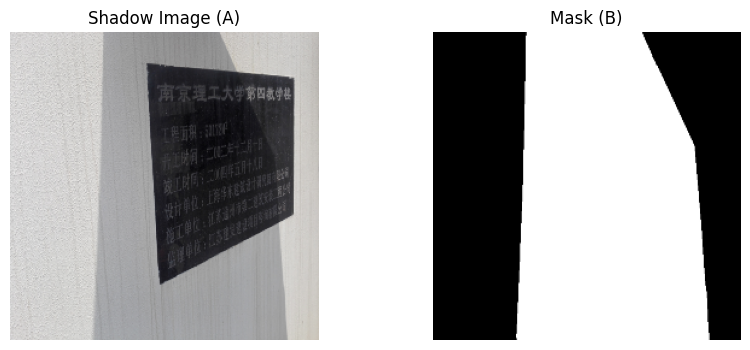

In [ ]:
i = 0  # change index to browse samples

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.title("Shadow Image (A)")
plt.imshow(X[i])
plt.axis("off")

plt.subplot(1,2,2)
plt.title("Mask (B)")
plt.imshow(y[i].squeeze(), cmap="gray")
plt.axis("off")

plt.show()

Build Model

In [ ]:
def conv_block(x, filters):
    x = layers.Conv2D(filters, 3, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    x = layers.Conv2D(filters, 3, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    return x


def encoder_block(x, filters):
    c = conv_block(x, filters)
    p = layers.MaxPooling2D((2, 2))(c)
    return c, p


def decoder_block(x, skip, filters):
    x = layers.UpSampling2D((2, 2))(x)
    x = layers.Concatenate()([x, skip])
    x = conv_block(x, filters)
    return x


def build_unet(input_shape=(256, 256, 3)):
    inputs = layers.Input(input_shape)

    # Encoder
    s1, p1 = encoder_block(inputs, 64)
    s2, p2 = encoder_block(p1, 128)
    s3, p3 = encoder_block(p2, 256)
    s4, p4 = encoder_block(p3, 512)

    # Bottleneck
    b = conv_block(p4, 1024)

    # Decoder
    d1 = decoder_block(b, s4, 512)
    d2 = decoder_block(d1, s3, 256)
    d3 = decoder_block(d2, s2, 128)
    d4 = decoder_block(d3, s1, 64)

    outputs = layers.Conv2D(1, 1, activation="sigmoid")(d4)

    model = Model(inputs, outputs)
    return model


model = build_unet()
model.summary()